wrote /home/fenghuang/workspace/rope-first-principle/assets/equal_distance_animation.gif


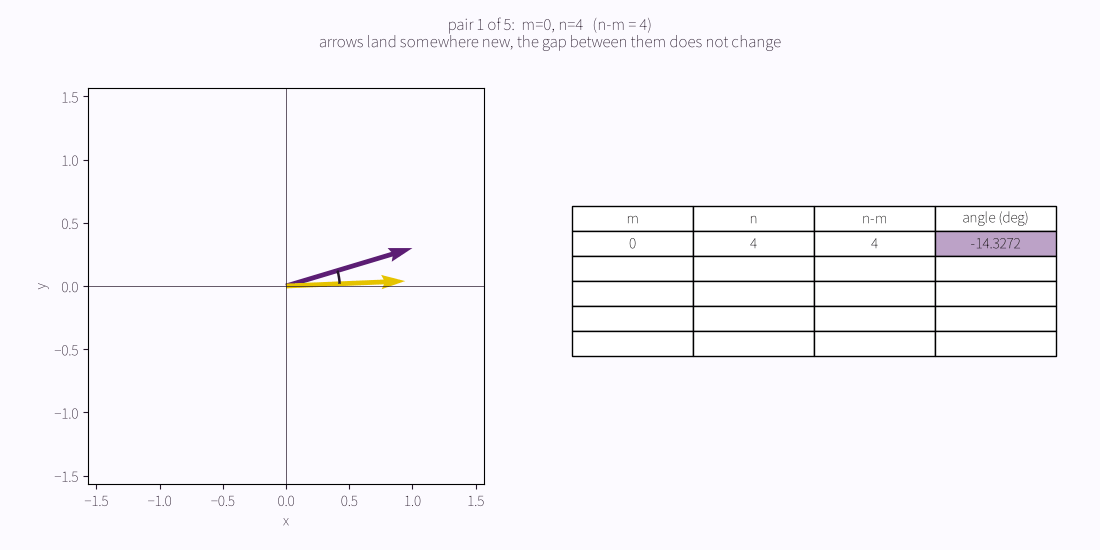

In [8]:
"""Equal relative distance yields equal angle: animated with progressive table.

Each frame jumps to a different position pair (m, n). The two arrows land
at completely different orientations from frame to frame, but the arc
between them stays the same size. Below the plot, a table fills one row
per frame with the stored values: m, n, n-m, and the measured angle.

By the last frame the table tells the story in columns: m and n vary
irregularly, n-m is constant, and the angle column repeats the exact
same number all the way down.

The pairs are deliberately not uniform shifts of one another; the only
thing they share is the difference n - m.

Self-contained for Google Colab. Run the whole file in one cell; the GIF
displays inline and is saved as equal_distance_animation.gif.
"""

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.animation import FuncAnimation, PillowWriter
from matplotlib.patches import Arc

import os

try:
    _THIS_DIR = os.path.dirname(os.path.abspath(__file__))
except NameError:
    # __file__ is undefined when this script is exec()'d or pasted into a
    # notebook/Colab cell rather than run as a standalone file. Fall back
    # to the current working directory in that case.
    _THIS_DIR = os.getcwd()
_ASSETS_DIR = os.path.join(_THIS_DIR, "assets")
os.makedirs(_ASSETS_DIR, exist_ok=True)
OUTPUT_PATH = os.path.join(_ASSETS_DIR, "equal_distance_animation.gif")

# === PALET WARNA BRAND ===
PRIMARY = "#5C1D74"
SECONDARY = "#E5C300"
TEXT_COLOR = "#25172A"
BG_COLOR = "#FCFAFF"


def _hex_to_rgb(h: str) -> tuple[float, float, float]:
    h = h.lstrip("#")
    return tuple(int(h[i:i + 2], 16) for i in (0, 2, 4))


def _rgb_to_hex(rgb: tuple[float, float, float]) -> str:
    return "#%02X%02X%02X" % tuple(max(0, min(255, round(c))) for c in rgb)


def _mix(c1: str, c2: str, t: float) -> str:
    """t=0 -> c1, t=1 -> c2."""
    r1, g1, b1 = _hex_to_rgb(c1)
    r2, g2, b2 = _hex_to_rgb(c2)
    return _rgb_to_hex((r1 + (r2 - r1) * t, g1 + (g2 - g1) * t, b1 + (b2 - b1) * t))


def _sequential_palette(n: int, c1: str = PRIMARY, c2: str = SECONDARY) -> list[str]:
    """N warna berurutan dari c1 ke c2, dipakai untuk membedakan N pasangan
    (m, n) satu sama lain."""
    if n <= 1:
        return [c1]
    return [_mix(c1, c2, i / (n - 1)) for i in range(n)]


def rotate_2d(v: np.ndarray, position: int, theta: float) -> np.ndarray:
    """Rotate a 2D vector by (position * theta) radians."""
    angle = position * theta
    c, s = np.cos(angle), np.sin(angle)
    rotation_matrix = np.array([[c, -s], [s, c]])
    return rotation_matrix @ v


def signed_angle_deg(u: np.ndarray, v: np.ndarray) -> float:
    """Return the angle of v relative to u in degrees, counter-clockwise positive."""
    angle_u = np.degrees(np.arctan2(u[1], u[0]))
    angle_v = np.degrees(np.arctan2(v[1], v[0]))
    return angle_v - angle_u


def build_animation(
    theta: float = 0.15,
    a0: np.ndarray = np.array([1.0, 0.3]),
    b0: np.ndarray = np.array([0.8, -0.5]),
    pairs: list[tuple[int, int]] = None,
    output_path: str = OUTPUT_PATH,
) -> None:
    if pairs is None:
        # Unrelated pairs sharing only their difference (n - m = 4).
        pairs = [(0, 4), (7, 11), (23, 27), (58, 62), (131, 135)]

    rotated = [
        (rotate_2d(a0, m, theta), rotate_2d(b0, n, theta))
        for m, n in pairs
    ]
    deltas = [signed_angle_deg(a, b) for a, b in rotated]

    # === LAYOUT: KANVAS KESELURUHAN ===
    # Lebar > tinggi -> mendukung dua panel berdampingan (bukan stack vertikal).
    fig = plt.figure(figsize=(11, 5.5))
    fig.patch.set_facecolor(BG_COLOR)

    # === LAYOUT: PANEL KIRI (quiver / vektor) ===
    # [left, bottom, width, height]. Mengisi kolom kiri, tinggi hampir penuh,
    # menyisakan ruang atas untuk fig.suptitle (lihat blok judul di bawah).
    ax_vec = fig.add_axes([0.06, 0.12, 0.40, 0.72])

    # === LAYOUT: PANEL KANAN (tabel) ===
    # Kolom kanan, disejajarkan vertikal (bottom & height sama pola dengan ax_vec)
    # supaya kedua panel terlihat rata secara visual.
    ax_table = fig.add_axes([0.52, 0.20, 0.44, 0.58])
    ax_table.axis("off")
    ax_vec.set_facecolor(BG_COLOR)
    ax_table.set_facecolor(BG_COLOR)

    max_norm = max(np.linalg.norm(a0), np.linalg.norm(b0))
    limit = 1.5 * max_norm
    ax_vec.set_xlim(-limit, limit)
    ax_vec.set_ylim(-limit, limit)
    ax_vec.set_aspect("equal")
    ax_vec.axhline(0, color=TEXT_COLOR, linewidth=0.5)
    ax_vec.axvline(0, color=TEXT_COLOR, linewidth=0.5)
    ax_vec.set_xlabel("x", color=TEXT_COLOR)
    ax_vec.set_ylabel("y", color=TEXT_COLOR)
    ax_vec.tick_params(colors=TEXT_COLOR)

    # 5-stop diskrit, satu warna per pasangan (m, n) -- dipakai untuk
    # menandai baris tabel yang aktif di tiap frame.
    row_colors = _sequential_palette(len(pairs))

    # Table: header + one row per pair, filled progressively.
    col_labels = ["m", "n", "n-m", "angle (deg)"]
    table_data = [["", "", "", ""] for _ in pairs]
    table = ax_table.table(
        cellText=table_data,
        colLabels=col_labels,
        loc="center",
        cellLoc="center",
    )
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1, 1.5)

    def update(frame_idx: int):
        m, n = pairs[frame_idx]
        a, b = rotated[frame_idx]
        delta = deltas[frame_idx]

        # === JUDUL: fig.suptitle, bukan ax_vec.set_title ===
        # Alasan pindah: ax_vec sekarang cuma separuh lebar figure (panel kiri),
        # judul dua baris akan terpotong/menyempit kalau dipaksa muat di situ.
        # fig.suptitle mengambil lebar PENUH figure dan y=0.97 memberi margin
        # tetap dari tepi atas, jadi tidak akan mepet seperti sebelumnya.
        fig.suptitle(
            f"pair {frame_idx + 1} of {len(pairs)}:  m={m}, n={n}   (n-m = {n - m})\n"
            f"arrows land somewhere new, the gap between them does not change",
            y=0.97, fontsize=11, color=TEXT_COLOR,
        )

        # Clear dynamic artists from the previous frame.
        for artist in list(ax_vec.patches):
            artist.remove()
        for artist in list(ax_vec.collections):
            artist.remove()
        for artist in list(ax_vec.lines):
            artist.remove()

        # Redraw axes lines removed by the cleanup above.
        ax_vec.axhline(0, color=TEXT_COLOR, linewidth=0.5)
        ax_vec.axvline(0, color=TEXT_COLOR, linewidth=0.5)

        # Current pair of arrows. Vektor a selalu PRIMARY, vektor b selalu
        # SECONDARY -- warna konsisten lintas frame karena keduanya mewakili
        # peran yang sama (a0/b0 dasar), bukan kategori yang berubah per frame.
        ax_vec.quiver(0, 0, a[0], a[1], angles="xy", scale_units="xy", scale=1,
                      color=PRIMARY, width=0.012)
        ax_vec.quiver(0, 0, b[0], b[1], angles="xy", scale_units="xy", scale=1,
                      color=SECONDARY, width=0.012)

        # Arc marking the angle between them. TEXT_COLOR supaya arc terlihat
        # netral, beda dari kedua warna vektor.
        angle_a = np.degrees(np.arctan2(a[1], a[0]))
        angle_b = np.degrees(np.arctan2(b[1], b[0]))
        arc_radius = 0.45 * min(np.linalg.norm(a), np.linalg.norm(b))
        arc = Arc((0, 0), 2 * arc_radius, 2 * arc_radius,
                  angle=0, theta1=min(angle_a, angle_b), theta2=max(angle_a, angle_b),
                  color=TEXT_COLOR, linewidth=1.8)
        ax_vec.add_patch(arc)

        # Fill this frame's table row. Tint terang dari row_colors[frame_idx]
        # (bukan warna jenuh penuh) supaya teks angka tetap kontras.
        table[frame_idx + 1, 0].get_text().set_text(str(m))
        table[frame_idx + 1, 1].get_text().set_text(str(n))
        table[frame_idx + 1, 2].get_text().set_text(str(n - m))
        table[frame_idx + 1, 3].get_text().set_text(f"{delta:.4f}")
        table[frame_idx + 1, 3].set_facecolor(_mix(row_colors[frame_idx], BG_COLOR, 0.6))

        return []

    anim = FuncAnimation(
        fig, update, frames=len(pairs), interval=1200, blit=False, repeat=True
    )

    writer = PillowWriter(fps=0.8)
    anim.save(output_path, writer=writer)
    plt.close(fig)
    print(f"wrote {output_path}")


def main() -> None:
    build_animation()

    # Auto-display in Colab/Jupyter without needing a separate cell.
    try:
        from IPython.display import Image as IPImage
        from IPython.display import display
        display(IPImage(OUTPUT_PATH))
    except ImportError:
        pass


if __name__ == "__main__":
    main()

findfont: Failed to find font weight normal, now using 100.


wrote /home/fenghuang/workspace/rope-first-principle/assets/attention_mismatch_animation.gif


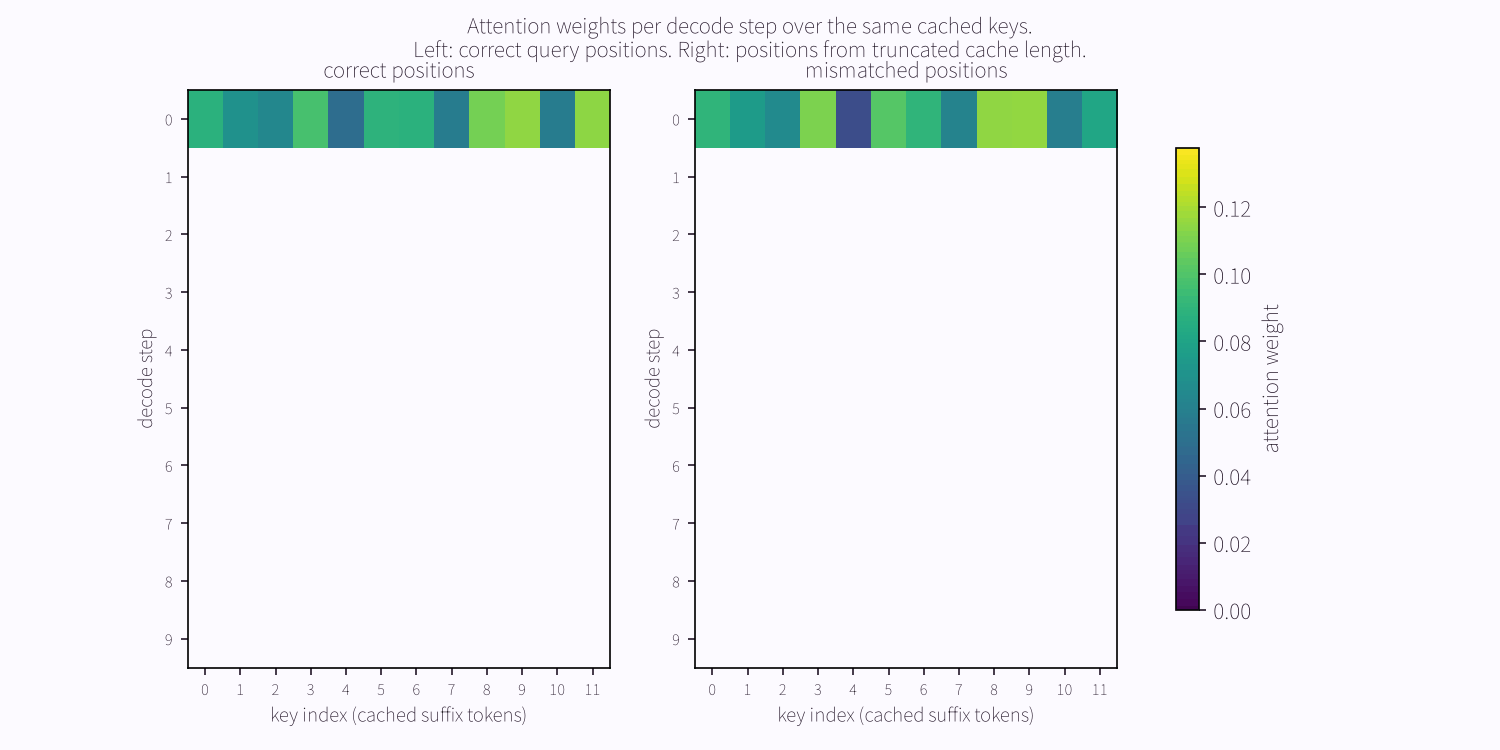

In [9]:
"""Animated attention heatmaps, correct vs mismatched positions (imshow +
colorbar, subplots(1,2)).

Scenario: a KV cache of prefix + suffix tokens is truncated to the
suffix. The remaining keys keep the rotations from their original
absolute positions. The model then decodes several steps. Each decode
step computes attention weights over the same fixed keys, using either:

  left panel  : the correct query position (continuing the full history)
  right panel : a query position derived from the truncated cache length

Each frame adds one row to both heatmaps: row t = attention weights of
decode step t over the suffix keys. Color scale is shared. The rows fill
top to bottom as decoding proceeds, so by the last frame the two panels
show the full weight matrices side by side and the drift between them is
visible as a different color pattern, not as any error or crash.

Self-contained for Google Colab. Run the whole file in one cell; the GIF
displays inline and is saved as attention_mismatch_animation.gif.
"""

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.animation import FuncAnimation, PillowWriter

import os

try:
    _THIS_DIR = os.path.dirname(os.path.abspath(__file__))
except NameError:
    # __file__ is undefined when this script is exec()'d or pasted into a
    # notebook/Colab cell rather than run as a standalone file. Fall back
    # to the current working directory in that case.
    _THIS_DIR = os.getcwd()
_ASSETS_DIR = os.path.join(_THIS_DIR, "assets")
os.makedirs(_ASSETS_DIR, exist_ok=True)
OUTPUT_PATH = os.path.join(_ASSETS_DIR, "attention_mismatch_animation.gif")

# === PALET WARNA BRAND ===
# Dipakai untuk semua elemen non-heatmap (judul, label, background, colorbar).
# Heatmap sengaja TETAP pakai viridis (lihat cmap="viridis" di imshow) karena
# itu colormap kontinu yang perceptually uniform -- mengganti dengan gradasi
# custom dua-titik berisiko membuat sebagian rentang nilai terlihat lebih
# rapat secara visual padahal jaraknya sama secara angka.
PRIMARY = "#5C1D74"
SECONDARY = "#E5C300"
TEXT_COLOR = "#25172A"
BG_COLOR = "#FCFAFF"


def inverse_frequencies(dim: int, base: float = 10000.0) -> np.ndarray:
    i = np.arange(dim // 2)
    return base ** (-2.0 * i / dim)


def apply_rope(x: np.ndarray, position: int, freqs: np.ndarray) -> np.ndarray:
    """Adjacent-pair rotary encoding on a single vector."""
    out = np.empty_like(x)
    angles = position * freqs
    cos, sin = np.cos(angles), np.sin(angles)
    x_even, x_odd = x[0::2], x[1::2]
    out[0::2] = x_even * cos - x_odd * sin
    out[1::2] = x_even * sin + x_odd * cos
    return out


def attention_weights(query: np.ndarray, query_position: int,
                      keys: np.ndarray, key_positions: np.ndarray,
                      freqs: np.ndarray) -> np.ndarray:
    """Softmax attention weights of one query over a fixed set of keys.

    Identity projections: the only transformation is the rotary encoding,
    so any difference between two runs is attributable to positions alone.
    """
    dim = query.shape[-1]
    q = apply_rope(query, query_position, freqs)
    scores = np.array([
        np.dot(q, apply_rope(keys[j], int(key_positions[j]), freqs))
        for j in range(keys.shape[0])
    ]) / np.sqrt(dim)
    exp = np.exp(scores - scores.max())
    return exp / exp.sum()


def build_animation(
    dim: int = 16,
    prefix_len: int = 20,
    suffix_len: int = 12,
    n_decode_steps: int = 10,
    seed: int = 0,
    output_path: str = OUTPUT_PATH,
) -> None:
    rng = np.random.default_rng(seed)
    freqs = inverse_frequencies(dim)
    total = prefix_len + suffix_len

    keys = rng.normal(size=(suffix_len, dim)) * 0.5
    queries = rng.normal(size=(n_decode_steps, dim)) * 0.5

    # Cached keys keep their original absolute positions.
    key_positions = np.arange(prefix_len, total)

    weights_correct = np.full((n_decode_steps, suffix_len), np.nan)
    weights_buggy = np.full((n_decode_steps, suffix_len), np.nan)
    for t in range(n_decode_steps):
        weights_correct[t] = attention_weights(
            queries[t], total + t, keys, key_positions, freqs)
        weights_buggy[t] = attention_weights(
            queries[t], suffix_len + t, keys, key_positions, freqs)

    vmax = max(weights_correct.max(), weights_buggy.max())

    fig, (ax_l, ax_r) = plt.subplots(1, 2, figsize=(10, 5), dpi=150)
    fig.patch.set_facecolor(BG_COLOR)
    ax_l.set_facecolor(BG_COLOR)
    ax_r.set_facecolor(BG_COLOR)
    fig.suptitle(
        "Attention weights per decode step over the same cached keys.\n"
        "Left: correct query positions. Right: positions from truncated cache length.",
        fontsize=10, color=TEXT_COLOR,
    )

    masked = np.full_like(weights_correct, np.nan)
    # cmap="viridis" dipertahankan (lihat catatan di blok palet di atas) --
    # ini satu-satunya elemen yang TIDAK ikut branding.
    im_l = ax_l.imshow(masked.copy(), vmin=0, vmax=vmax, aspect="auto",
                       cmap="viridis", interpolation="nearest")
    im_r = ax_r.imshow(masked.copy(), vmin=0, vmax=vmax, aspect="auto",
                       cmap="viridis", interpolation="nearest")

    for ax, title in ((ax_l, "correct positions"), (ax_r, "mismatched positions")):
        ax.set_xlabel("key index (cached suffix tokens)", fontsize=9, color=TEXT_COLOR)
        ax.set_ylabel("decode step", fontsize=9, color=TEXT_COLOR)
        ax.set_title(title, fontsize=10, color=TEXT_COLOR)
        ax.set_xticks(range(suffix_len))
        ax.set_yticks(range(n_decode_steps))
        ax.tick_params(labelsize=7, colors=TEXT_COLOR)

    cbar = fig.colorbar(im_l, ax=[ax_l, ax_r], shrink=0.8, label="attention weight")
    cbar.set_label("attention weight", color=TEXT_COLOR)
    cbar.ax.yaxis.set_tick_params(color=TEXT_COLOR, labelcolor=TEXT_COLOR)

    def update(frame_idx: int):
        shown_correct = np.full_like(weights_correct, np.nan)
        shown_buggy = np.full_like(weights_buggy, np.nan)
        shown_correct[: frame_idx + 1] = weights_correct[: frame_idx + 1]
        shown_buggy[: frame_idx + 1] = weights_buggy[: frame_idx + 1]
        im_l.set_data(shown_correct)
        im_r.set_data(shown_buggy)
        return [im_l, im_r]

    anim = FuncAnimation(fig, update, frames=n_decode_steps,
                         interval=600, blit=False, repeat=True)
    writer = PillowWriter(fps=1.6)
    anim.save(output_path, writer=writer)
    plt.close(fig)
    print(f"wrote {output_path}")


def main() -> None:
    build_animation()
    try:
        from IPython.display import Image as IPImage
        from IPython.display import display
        display(IPImage(OUTPUT_PATH))
    except ImportError:
        pass


if __name__ == "__main__":
    main()

wrote /home/fenghuang/workspace/rope-first-principle/assets/frequency_spectrum_animation.gif


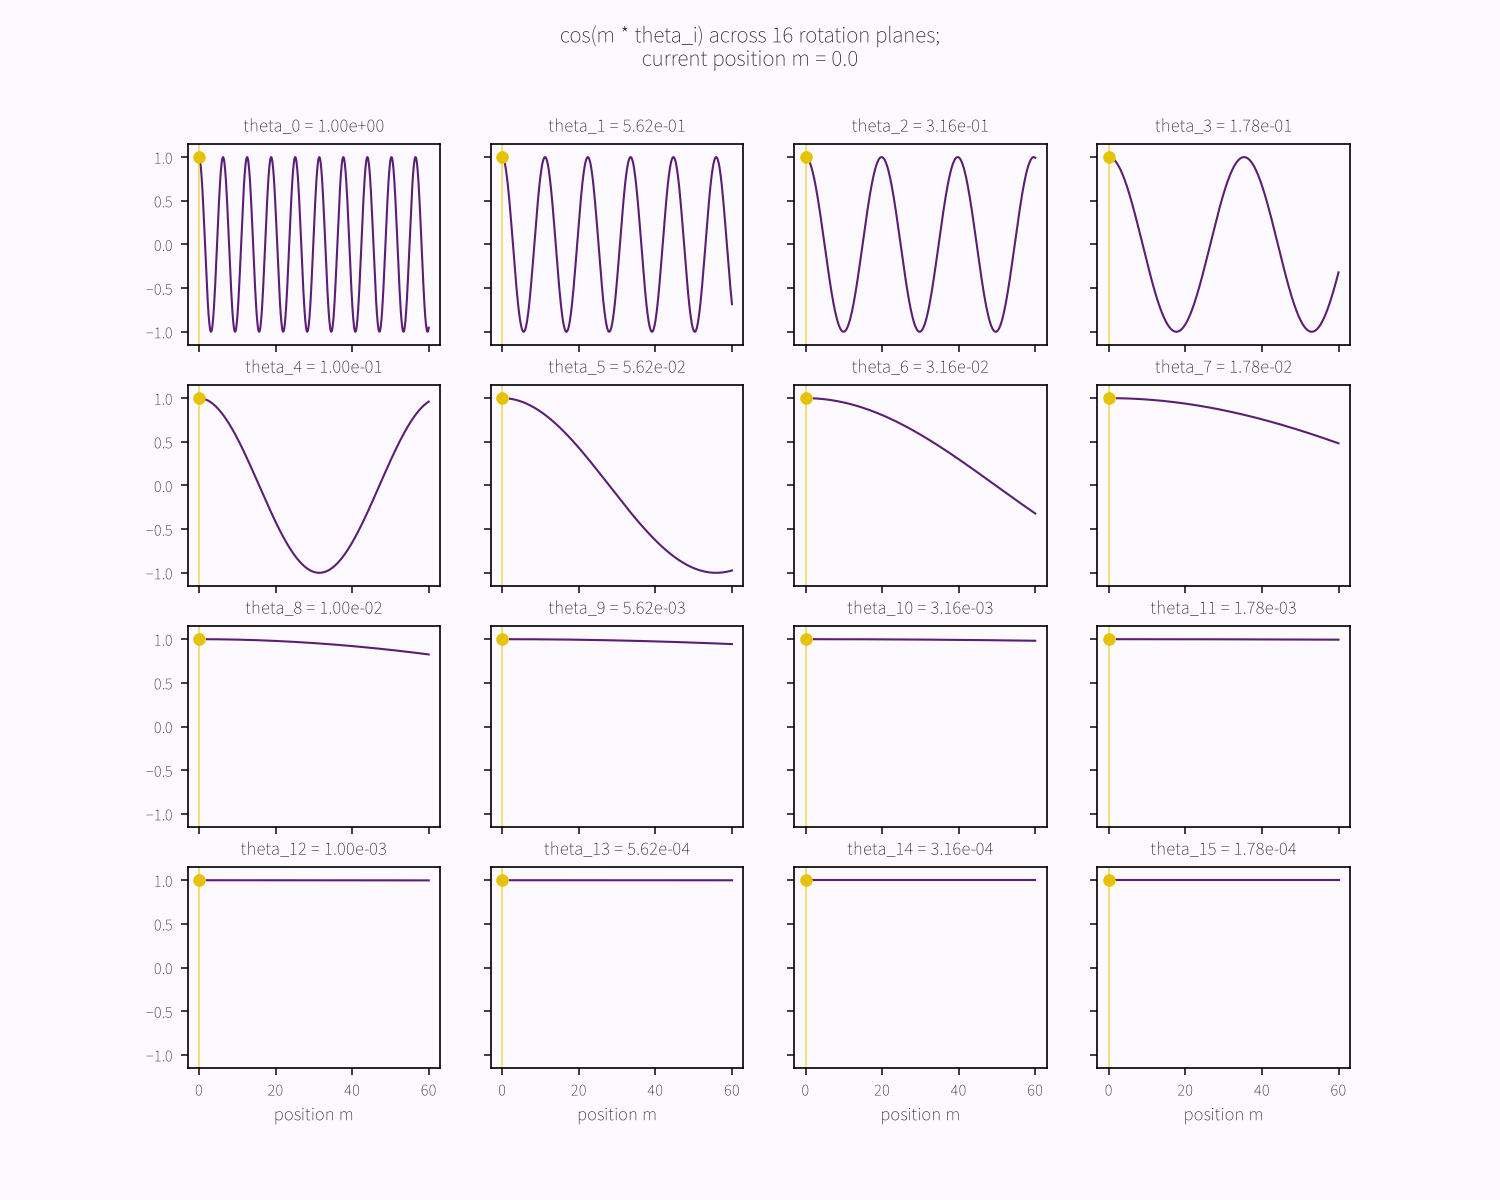

In [10]:
"""Animated frequency spectrum, 4x4 grid (plot, subplots(4,4, sharex, sharey)).

Sixteen rotation planes from the RoPE spectrum theta_i = base^(-2i/dim),
each subplot showing cos(m * theta_i) against position m. The full curve
is drawn statically; a red marker and a vertical line sweep through
position m frame by frame.

What to watch: at any single frame, the sixteen marker heights together
form a signature for that position. Fast planes (top-left) oscillate
rapidly and alone would alias distant positions onto the same value;
slow planes (bottom-right) barely move and alone could not tell nearby
positions apart. The combination is what makes each position
distinguishable.

Self-contained for Google Colab. Run the whole file in one cell; the GIF
displays inline and is saved as frequency_spectrum_animation.gif.
"""

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.animation import FuncAnimation, PillowWriter

import os

try:
    _THIS_DIR = os.path.dirname(os.path.abspath(__file__))
except NameError:
    # __file__ is undefined when this script is exec()'d or pasted into a
    # notebook/Colab cell rather than run as a standalone file. Fall back
    # to the current working directory in that case.
    _THIS_DIR = os.getcwd()
_ASSETS_DIR = os.path.join(_THIS_DIR, "assets")
os.makedirs(_ASSETS_DIR, exist_ok=True)
OUTPUT_PATH = os.path.join(_ASSETS_DIR, "frequency_spectrum_animation.gif")

# === PALET WARNA BRAND ===
# Kurva 16 panel sengaja tetap SATU warna (PRIMARY) di semua panel --
# fokus visual ada di marker yang bergerak, bukan pada perbedaan antar-panel.
# Marker/vline pakai SECONDARY supaya kontras tinggi terhadap kurva ungu.
PRIMARY = "#5C1D74"
SECONDARY = "#E5C300"
TEXT_COLOR = "#25172A"
BG_COLOR = "#FCFAFF"


def inverse_frequencies(dim: int, base: float = 10000.0) -> np.ndarray:
    i = np.arange(dim // 2)
    return base ** (-2.0 * i / dim)


def build_animation(
    dim: int = 32,                # 16 planes -> 4x4 grid
    base: float = 10000.0,
    max_position: int = 60,
    n_frames: int = 20,
    output_path: str = OUTPUT_PATH,
) -> None:
    freqs = inverse_frequencies(dim, base)
    positions_fine = np.linspace(0, max_position, 600)
    frame_positions = np.linspace(0, max_position, n_frames)

    fig, axes = plt.subplots(4, 4, figsize=(10, 8), dpi=150, sharex=True, sharey=True)
    fig.patch.set_facecolor(BG_COLOR)
    fig.suptitle("cos(m * theta_i) across 16 rotation planes;\nmarker = current position m",
                 fontsize=10, color=TEXT_COLOR)

    markers, vlines = [], []
    for idx, ax in enumerate(axes.flat):
        ax.set_facecolor(BG_COLOR)
        ax.plot(positions_fine, np.cos(positions_fine * freqs[idx]),
                color=PRIMARY, linewidth=1.0)
        ax.set_title(f"theta_{idx} = {freqs[idx]:.2e}", fontsize=8, color=TEXT_COLOR)
        ax.set_ylim(-1.15, 1.15)
        ax.tick_params(colors=TEXT_COLOR, labelsize=7)
        marker, = ax.plot([], [], "o", color=SECONDARY, markersize=5)
        vline = ax.axvline(0, color=SECONDARY, linewidth=0.8, alpha=0.6)
        markers.append(marker)
        vlines.append(vline)

    for ax in axes[-1, :]:
        ax.set_xlabel("position m", fontsize=8, color=TEXT_COLOR)

    def update(frame_idx: int):
        m = frame_positions[frame_idx]
        fig.suptitle(
            f"cos(m * theta_i) across 16 rotation planes;\ncurrent position m = {m:.1f}",
            fontsize=10, color=TEXT_COLOR,
        )
        for idx, (marker, vline) in enumerate(zip(markers, vlines)):
            marker.set_data([m], [np.cos(m * freqs[idx])])
            vline.set_xdata([m, m])
        return markers + vlines

    anim = FuncAnimation(fig, update, frames=n_frames,
                         interval=500, blit=False, repeat=True)
    writer = PillowWriter(fps=2)
    anim.save(output_path, writer=writer)
    plt.close(fig)
    print(f"wrote {output_path}")


def main() -> None:
    build_animation()
    try:
        from IPython.display import Image as IPImage
        from IPython.display import display
        display(IPImage(OUTPUT_PATH))
    except ImportError:
        pass


if __name__ == "__main__":
    main()


findfont: Failed to find font weight normal, now using 100.
findfont: Failed to find font weight normal, now using 100.
findfont: Failed to find font weight bold, now using 100.
findfont: Failed to find font weight normal, now using 100.
findfont: Failed to find font weight normal, now using 100.
findfont: Failed to find font weight bold, now using 100.
findfont: Failed to find font weight normal, now using 100.


wrote /home/fenghuang/workspace/rope-first-principle/../assets/score_matrix_animation.gif


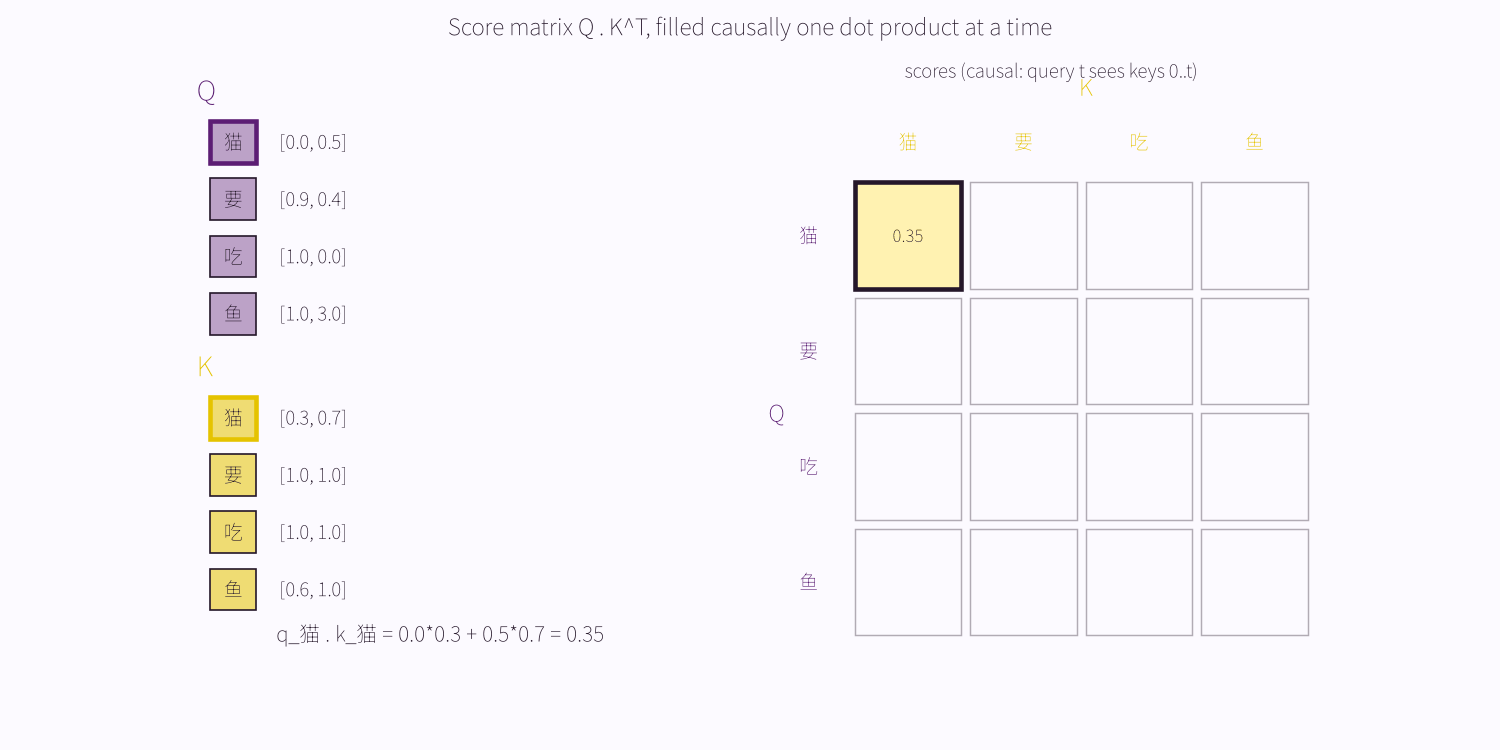

In [ ]:
"""Animated Q.K score matrix, filled causally one cell per frame.

Layout follows the common attention-explainer diagram: the Q and K
vector lists on the left, the score grid on the right. Each frame
highlights one (query, key) pair, computes their dot product for real,
and fills the corresponding cell with its value and a color mapped to
its magnitude. Cells fill in causal order: query t only attends to keys
0..t, so the grid fills as a lower triangle.

Vectors here are small 2D examples so every dot product is checkable by
hand from the numbers shown on the left.

Self-contained for Google Colab. Run the whole file in one cell; the GIF
displays inline and is saved as score_matrix_animation.gif.
"""

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import numpy as np
from matplotlib.animation import FuncAnimation, PillowWriter
from matplotlib.patches import Rectangle

import glob
import os

try:
    _THIS_DIR = os.path.dirname(os.path.abspath(__file__))
except NameError:
    # __file__ is undefined when this script is exec()'d or pasted into a
    # notebook/Colab cell rather than run as a standalone file. Fall back
    # to the current working directory in that case.
    _THIS_DIR = os.getcwd()
_ASSETS_DIR = os.path.join(_THIS_DIR, "assets")
os.makedirs(_ASSETS_DIR, exist_ok=True)
OUTPUT_PATH = os.path.join(_ASSETS_DIR, "score_matrix_animation.gif")


def _find_cjk_font() -> str | None:
    """Locate a font file with Simplified-Chinese glyph coverage on this
    system, returning a path usable with FontProperties(fname=...).

    Matplotlib's own font cache often registers only ONE family name per
    .ttc file (e.g. it may see "Noto Sans CJK JP" but never learn that the
    same file also contains an "SC" face) -- so tokens like the ones this
    script uses (mao/yao/chi/yu written as Han characters) can silently
    fall back to the ".notdef" tofu box even when a CJK font is installed.
    To sidestep that, this walks common font directories directly and, for
    any .ttc collection, opens it with fontTools and extracts the specific
    face whose name contains "SC" as a standalone file (cached in the
    assets dir so this only happens once).

    Returns None if nothing is found -- callers should fall back to Latin
    (pinyin) rendering and print an install hint rather than fail.
    """
    cached = os.path.join(_ASSETS_DIR, "_cjk_sc_extracted.otf")
    if os.path.exists(cached):
        return cached

    search_patterns = [
        "/usr/share/fonts/**/*NotoSansCJK*",
        "/usr/share/fonts/**/*NotoSerifCJK*",
        "/usr/share/fonts/**/*wqy*",
        "/usr/share/fonts/**/*CJK*",
        "/usr/share/fonts/**/*cjk*",
        os.path.expanduser("~/.fonts/**/*CJK*"),
    ]
    candidates: list[str] = []
    for pattern in search_patterns:
        candidates.extend(glob.glob(pattern, recursive=True))

    for path in candidates:
        try:
            if path.lower().endswith(".ttc"):
                from fontTools.ttLib import TTCollection
                coll = TTCollection(path)
                sc_face = None
                for font in coll.fonts:
                    name = font["name"].getDebugName(4) or ""
                    if "SC" in name.split():
                        sc_face = font
                        break
                # Kalau tidak ada face SC eksplisit (mis. font non-Noto),
                # pakai face pertama saja -- lebih baik dari tidak sama sekali.
                face = sc_face if sc_face is not None else coll.fonts[0]
                face.save(cached)
                return cached
            else:
                return path  # sudah single-face (.otf/.ttf), pakai langsung
        except Exception:
            continue
    return None

# === PALET WARNA BRAND ===
# Heatmap sel skor (score_color, cmap YlOrBr) sengaja TETAP -- itu colormap
# sekuensial untuk nilai kuantitatif kontinu (dot product Q.K), sama alasan
# dengan viridis di anim_attention_mismatch.py. Semua elemen LAIN (kotak
# Q/K, label, judul, grid line) ikut branding: Q selalu PRIMARY, K selalu
# SECONDARY -- konsisten dengan peran a/b di script-script sebelumnya.
PRIMARY = "#5C1D74"
SECONDARY = "#E5C300"
TEXT_COLOR = "#25172A"
BG_COLOR = "#FCFAFF"


def _hex_to_rgb(h: str) -> tuple[float, float, float]:
    h = h.lstrip("#")
    return tuple(int(h[i:i + 2], 16) for i in (0, 2, 4))


def _rgb_to_hex(rgb: tuple[float, float, float]) -> str:
    return "#%02X%02X%02X" % tuple(max(0, min(255, round(c))) for c in rgb)


def _mix(c1: str, c2: str, t: float) -> str:
    """t=0 -> c1, t=1 -> c2."""
    r1, g1, b1 = _hex_to_rgb(c1)
    r2, g2, b2 = _hex_to_rgb(c2)
    return _rgb_to_hex((r1 + (r2 - r1) * t, g1 + (g2 - g1) * t, b1 + (b2 - b1) * t))


# Tint terang untuk kotak Q/K -- bukan warna jenuh penuh, supaya teks token
# di atasnya (TEXT_COLOR) tetap kontras.
Q_BOX_TINT = _mix(PRIMARY, BG_COLOR, 0.6)
K_BOX_TINT = _mix(SECONDARY, BG_COLOR, 0.45)
# Tint gelap dari TEXT_COLOR menuju BG_COLOR -- untuk grid line netral,
# lebih lembut dari gray generik tapi tetap terpisah dari palet Q/K.
GRID_LINE = _mix(TEXT_COLOR, BG_COLOR, 0.65)


def build_animation(
    tokens: list[str] = None,
    q_vectors: np.ndarray = None,
    k_vectors: np.ndarray = None,
    output_path: str = OUTPUT_PATH,
) -> None:
    if tokens is None:
        # 猫要吃鱼 (mao yao chi yu) -- kucing mau makan ikan.
        tokens = ["猫", "要", "吃", "鱼"]
    if q_vectors is None:
        q_vectors = np.array([[0.0, 0.5],
                              [0.9, 0.4],
                              [1.0, 0.0],
                              [1.0, 3.0]])
    if k_vectors is None:
        k_vectors = np.array([[0.3, 0.7],
                              [1.0, 1.0],
                              [1.0, 1.0],
                              [0.6, 1.0]])

    # Font CJK -- lihat _find_cjk_font() untuk alasan kenapa ini tidak cukup
    # ditangani lewat plt.rcParams["font.sans-serif"] = ["Noto Sans CJK SC"]
    # begitu saja (matplotlib sering tidak mengenali nama itu dari .ttc).
    cjk_font_path = _find_cjk_font()
    if cjk_font_path is not None:
        fm.fontManager.addfont(cjk_font_path)
        registered_name = fm.FontProperties(fname=cjk_font_path).get_name()
        plt.rcParams["font.family"] = "sans-serif"
        plt.rcParams["font.sans-serif"] = [registered_name, "DejaVu Sans"]
        # calc_text pakai family="monospace" secara eksplisit, jadi tidak
        # ikut font.sans-serif di atas -- perlu didaftarkan di sini juga,
        # atau baris "q_猫 . k_猫 = ..." akan balik jadi kotak kosong.
        plt.rcParams["font.monospace"] = [registered_name, "DejaVu Sans Mono"]
    else:
        print(
            "PERINGATAN: tidak ada font CJK ditemukan di sistem ini -- "
            "karakter Han pada token kemungkinan akan tampil sebagai kotak "
            "kosong. Di Colab, jalankan di cell terpisah sebelum ini:\n"
            "  !apt-get install -y fonts-noto-cjk\n"
            "lalu restart runtime."
        )

    n = len(tokens)
    scores = q_vectors @ k_vectors.T  # full matrix; only causal cells shown

    # Causal fill order: (0,0), (1,0), (1,1), (2,0), ...
    fill_order = [(t, j) for t in range(n) for j in range(t + 1)]

    causal_vals = [scores[t, j] for t, j in fill_order]
    vmin, vmax = min(causal_vals), max(causal_vals)
    cmap = plt.cm.YlOrBr

    def score_color(val: float):
        span = vmax - vmin if vmax > vmin else 1.0
        return cmap(0.15 + 0.7 * (val - vmin) / span)

    fig, (ax_vec, ax_grid) = plt.subplots(
        1, 2, figsize=(10, 5), dpi=150,
        gridspec_kw={"width_ratios": [1, 1.3]},
    )
    fig.patch.set_facecolor(BG_COLOR)
    fig.suptitle("Score matrix Q . K^T, filled causally one dot product at a time",
                 fontsize=11, color=TEXT_COLOR)

    # ---- Left panel: Q and K vector lists ----
    ax_vec.set_facecolor(BG_COLOR)
    ax_vec.set_xlim(0, 10)
    ax_vec.set_ylim(0, 10)
    ax_vec.axis("off")

    q_label_boxes, k_label_boxes = [], []
    row_height = 1.1
    q_top = 9.8
    k_gap = 0.8  # jarak antara blok Q dan blok K

    # k_top = posisi label "K" besar, tepat di atas kotak K pertama.
    q_last_box_bottom = (q_top - 0.8 - (n - 1) * row_height) - 0.4
    k_top = q_last_box_bottom - k_gap

    for i in range(n):
        y_q = q_top - 0.8 - i * row_height
        box = Rectangle((0.5, y_q - 0.4), 1.0, 0.8,
                        facecolor=Q_BOX_TINT, edgecolor=TEXT_COLOR, linewidth=0.8)
        ax_vec.add_patch(box)
        q_label_boxes.append(box)
        ax_vec.text(1.0, y_q, tokens[i], ha="center", va="center", fontsize=9,
                    color=TEXT_COLOR)
        ax_vec.text(2.0, y_q, f"[{q_vectors[i, 0]:.1f}, {q_vectors[i, 1]:.1f}]",
                    ha="left", va="center", fontsize=9, color=TEXT_COLOR)

        y_k = k_top - 0.8 - i * row_height
        box = Rectangle((0.5, y_k - 0.4), 1.0, 0.8,
                        facecolor=K_BOX_TINT, edgecolor=TEXT_COLOR, linewidth=0.8)
        ax_vec.add_patch(box)
        k_label_boxes.append(box)
        ax_vec.text(1.0, y_k, tokens[i], ha="center", va="center", fontsize=9,
                    color=TEXT_COLOR)
        ax_vec.text(2.0, y_k, f"[{k_vectors[i, 0]:.1f}, {k_vectors[i, 1]:.1f}]",
                    ha="left", va="center", fontsize=9, color=TEXT_COLOR)

    k_last_box_bottom = (k_top - 0.8 - (n - 1) * row_height) - 0.4
    calc_y = k_last_box_bottom - 0.6

    ax_vec.text(0.2, q_top, "Q", fontsize=13, color=PRIMARY, fontweight="bold")
    ax_vec.text(0.2, k_top, "K", fontsize=13, color=SECONDARY, fontweight="bold")
    calc_text = ax_vec.text(5.5, calc_y, "", fontsize=10, ha="center",
                            family="monospace", color=TEXT_COLOR)
    ax_vec.set_ylim(min(0, calc_y - 0.5), 10)

    # ---- Right panel: score grid ----
    ax_grid.set_facecolor(BG_COLOR)
    ax_grid.set_xlim(-0.8, n + 0.2)
    ax_grid.set_ylim(-0.8, n + 0.2)
    ax_grid.invert_yaxis()
    ax_grid.set_aspect("equal")
    ax_grid.axis("off")
    ax_grid.set_title("scores (causal: query t sees keys 0..t)", fontsize=9, color=TEXT_COLOR)

    cell_patches = {}
    cell_texts = {}
    for t in range(n):
        for j in range(n):
            rect = Rectangle((j, t), 0.92, 0.92,
                             facecolor=BG_COLOR, edgecolor=GRID_LINE, linewidth=0.7)
            ax_grid.add_patch(rect)
            cell_patches[(t, j)] = rect
            txt = ax_grid.text(j + 0.46, t + 0.46, "", ha="center", va="center",
                               fontsize=8, color=TEXT_COLOR)
            cell_texts[(t, j)] = txt

    for i in range(n):
        ax_grid.text(i + 0.46, -0.35, tokens[i], ha="center", va="center",
                     fontsize=9, color=SECONDARY)
        ax_grid.text(-0.4, i + 0.46, tokens[i], ha="center", va="center",
                     fontsize=9, color=PRIMARY)
    ax_grid.text(n / 2, -0.75, "K", ha="center", fontsize=11,
                 color=SECONDARY, fontweight="bold")
    ax_grid.text(-0.75, n / 2, "Q", va="center", fontsize=11,
                 color=PRIMARY, fontweight="bold")

    def update(frame_idx: int):
        t, j = fill_order[frame_idx]

        # Reset all fills up to this frame, then re-apply.
        for (tt, jj), rect in cell_patches.items():
            k = fill_order.index((tt, jj)) if (tt, jj) in fill_order else None
            if k is not None and k <= frame_idx:
                rect.set_facecolor(score_color(scores[tt, jj]))
                cell_texts[(tt, jj)].set_text(f"{scores[tt, jj]:.2f}")
            else:
                rect.set_facecolor(BG_COLOR)
                cell_texts[(tt, jj)].set_text("")
            rect.set_edgecolor(GRID_LINE)
            rect.set_linewidth(0.7)

        # Highlight the current cell and the vectors that produced it.
        cell_patches[(t, j)].set_edgecolor(TEXT_COLOR)
        cell_patches[(t, j)].set_linewidth(2.2)

        for i, box in enumerate(q_label_boxes):
            box.set_linewidth(2.2 if i == t else 0.8)
            box.set_edgecolor(PRIMARY if i == t else TEXT_COLOR)
        for i, box in enumerate(k_label_boxes):
            box.set_linewidth(2.2 if i == j else 0.8)
            box.set_edgecolor(SECONDARY if i == j else TEXT_COLOR)

        qv, kv = q_vectors[t], k_vectors[j]
        calc_text.set_text(
            f"q_{tokens[t]} . k_{tokens[j]} = "
            f"{qv[0]:.1f}*{kv[0]:.1f} + {qv[1]:.1f}*{kv[1]:.1f} "
            f"= {scores[t, j]:.2f}"
        )
        return []

    anim = FuncAnimation(fig, update, frames=len(fill_order),
                         interval=900, blit=False, repeat=True)
    writer = PillowWriter(fps=1.1)
    anim.save(output_path, writer=writer)
    plt.close(fig)
    print(f"wrote {output_path}")


def main() -> None:
    build_animation()
    try:
        from IPython.display import Image as IPImage
        from IPython.display import display
        display(IPImage(OUTPUT_PATH))
    except ImportError:
        pass


if __name__ == "__main__":
    main()

wrote /home/fenghuang/workspace/rope-first-principle/../assets/long_term_decay_animation.gif


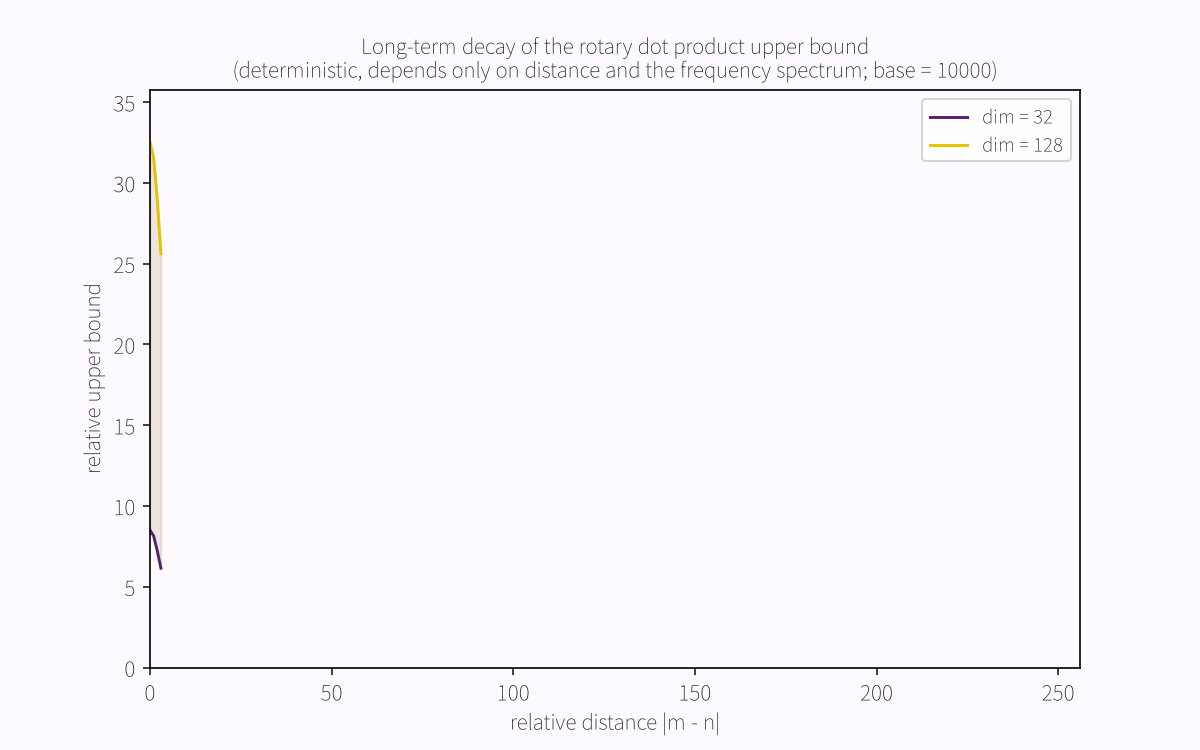

In [7]:
"""Animated long-term decay, single Axes (plot + fill_between).

Reproduces the decay property from the RoFormer paper (Figure 2,
Section 3.4.3), computed from scratch. The quantity plotted is the
relative upper bound of the rotary dot product:

    bound(d) = (1 / (dim/2)) * sum_j |S_j|,
    S_j = sum_{i=0}^{j-1} exp(1j * d * theta_i)

This is deterministic: it depends only on the relative distance d and
the frequency spectrum, not on any particular q and k. It bounds how
large the rotary dot product can get at that distance, which is why it,
and not the average dot product of random vectors, is the quantity that
exhibits clear decay. (The mean |q . k| over independent random vectors
stays nearly flat with distance; an earlier draft of this file plotted
that and showed almost no decay, which prompted the correction.)

Each frame extends the visible distance range left to right. Two curves
are shown for different head dimensions, with fill_between shading the
region between them to make the dim-dependence visible.

Self-contained for Google Colab. Run the whole file in one cell; the GIF
displays inline and is saved as long_term_decay_animation.gif.
"""

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.animation import FuncAnimation, PillowWriter

import os

try:
    _THIS_DIR = os.path.dirname(os.path.abspath(__file__))
except NameError:
    # __file__ is undefined when this script is exec()'d or pasted into a
    # notebook/Colab cell rather than run as a standalone file. Fall back
    # to the current working directory in that case.
    _THIS_DIR = os.getcwd()
_ASSETS_DIR = os.path.join(_THIS_DIR, "..", "assets")
os.makedirs(_ASSETS_DIR, exist_ok=True)
OUTPUT_PATH = os.path.join(_ASSETS_DIR, "long_term_decay_animation.gif")

# === PALET WARNA BRAND ===
PRIMARY = "#5C1D74"
SECONDARY = "#E5C300"
TEXT_COLOR = "#25172A"
BG_COLOR = "#FCFAFF"


def _hex_to_rgb(h: str) -> tuple[float, float, float]:
    h = h.lstrip("#")
    return tuple(int(h[i:i + 2], 16) for i in (0, 2, 4))


def _rgb_to_hex(rgb: tuple[float, float, float]) -> str:
    return "#%02X%02X%02X" % tuple(max(0, min(255, round(c))) for c in rgb)


def _mix(c1: str, c2: str, t: float) -> str:
    """t=0 -> c1, t=1 -> c2."""
    r1, g1, b1 = _hex_to_rgb(c1)
    r2, g2, b2 = _hex_to_rgb(c2)
    return _rgb_to_hex((r1 + (r2 - r1) * t, g1 + (g2 - g1) * t, b1 + (b2 - b1) * t))


# Fill_between netral: mix 50/50 primary-secondary (bukan salah satu warna
# kurva) supaya band terlihat sebagai wilayah "di antara", bukan condong ke
# salah satu dim.
FILL_COLOR = _mix(PRIMARY, SECONDARY, 0.5)


def inverse_frequencies(dim: int, base: float = 10000.0) -> np.ndarray:
    i = np.arange(dim // 2)
    return base ** (-2.0 * i / dim)


def relative_upper_bound(distance: int, freqs: np.ndarray) -> float:
    """The paper's decay quantity: mean of |S_j| over j, with
    S_j the partial sums of exp(1j * distance * theta_i)."""
    phases = np.exp(1j * distance * freqs)
    partial_sums = np.cumsum(phases)
    return float(np.mean(np.abs(partial_sums)))


def compute_decay_curve(dim: int, max_distance: int) -> np.ndarray:
    freqs = inverse_frequencies(dim)
    return np.array([
        relative_upper_bound(d, freqs) for d in range(max_distance + 1)
    ])


def build_animation(
    dims: tuple[int, int] = (32, 128),
    max_distance: int = 256,
    n_frames: int = 16,
    output_path: str = OUTPUT_PATH,
) -> None:
    distances = np.arange(max_distance + 1)
    curve_low = compute_decay_curve(dims[0], max_distance)
    curve_high = compute_decay_curve(dims[1], max_distance)

    fig, ax = plt.subplots(figsize=(8, 5), dpi=150)
    fig.patch.set_facecolor(BG_COLOR)
    ax.set_facecolor(BG_COLOR)
    ax.set_xlim(0, max_distance)
    top = max(curve_low.max(), curve_high.max())
    ax.set_ylim(0, top * 1.1)
    ax.set_xlabel("relative distance |m - n|", color=TEXT_COLOR)
    ax.set_ylabel("relative upper bound", color=TEXT_COLOR)
    ax.tick_params(colors=TEXT_COLOR)
    ax.set_title(
        "Long-term decay of the rotary dot product upper bound\n"
        f"(deterministic, depends only on distance and the frequency spectrum; base = 10000)",
        fontsize=10, color=TEXT_COLOR,
    )

    line_low, = ax.plot([], [], color=PRIMARY, linewidth=1.4,
                        label=f"dim = {dims[0]}")
    line_high, = ax.plot([], [], color=SECONDARY, linewidth=1.4,
                         label=f"dim = {dims[1]}")
    legend = ax.legend(loc="upper right", fontsize=9)
    for text in legend.get_texts():
        text.set_color(TEXT_COLOR)
    band_holder = [None]

    cut_points = np.linspace(4, len(distances), n_frames).astype(int)

    def update(frame_idx: int):
        cut = cut_points[frame_idx]
        line_low.set_data(distances[:cut], curve_low[:cut])
        line_high.set_data(distances[:cut], curve_high[:cut])
        if band_holder[0] is not None:
            band_holder[0].remove()
        band_holder[0] = ax.fill_between(
            distances[:cut],
            np.minimum(curve_low[:cut], curve_high[:cut]),
            np.maximum(curve_low[:cut], curve_high[:cut]),
            color=FILL_COLOR, alpha=0.15,
        )
        return [line_low, line_high, band_holder[0]]

    anim = FuncAnimation(fig, update, frames=n_frames,
                         interval=400, blit=False, repeat=True)
    writer = PillowWriter(fps=2.5)
    anim.save(output_path, writer=writer)
    plt.close(fig)
    print(f"wrote {output_path}")


def main() -> None:
    build_animation()
    try:
        from IPython.display import Image as IPImage
        from IPython.display import display
        display(IPImage(OUTPUT_PATH))
    except ImportError:
        pass


if __name__ == "__main__":
    main()